# 文件: chart_2_1.py

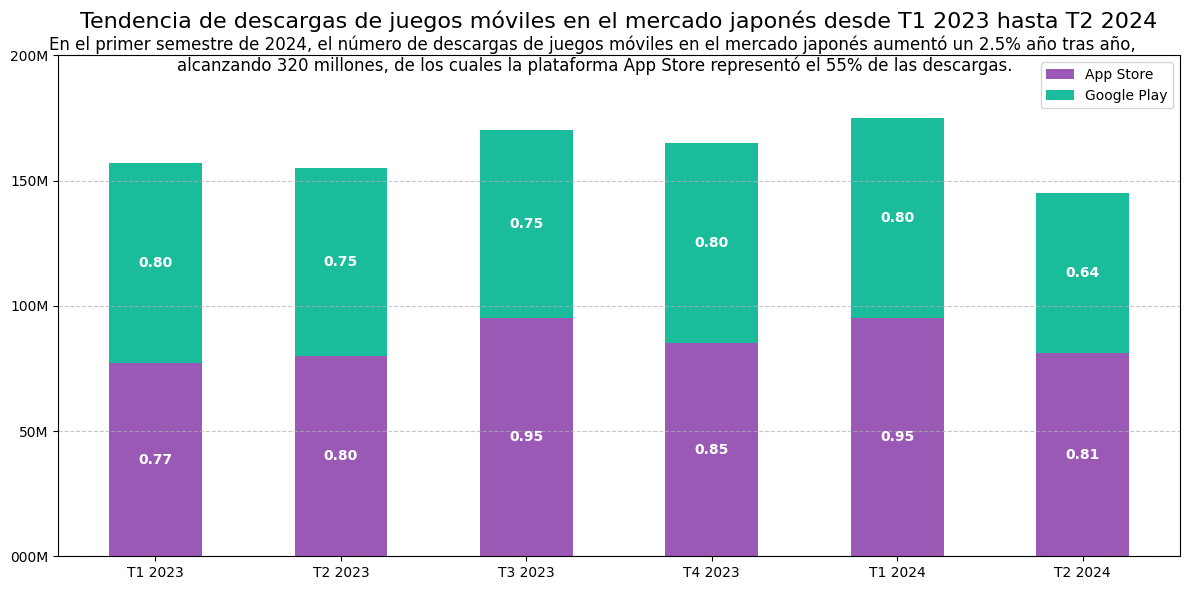

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Establecer datos trimestrales
trimestres = ['T1 2023', 'T2 2023', 'T3 2023', 'T4 2023', 'T1 2024', 'T2 2024']
# Datos de volumen de descargas de la App Store (en cientos de millones), ajustados para que T1 2024 + T2 2024 ≈ 1.76
app_store = [0.77, 0.8, 0.95, 0.85, 0.95, 0.81]
# Datos de volumen de descargas de Google Play (en cientos de millones), ajustados para que T1 2024 + T2 2024 ≈ 1.44
google_play = [0.8, 0.75, 0.75, 0.8, 0.8, 0.64]

x = np.arange(len(trimestres))  # Posiciones de las marcas en el eje x
ancho = 0.5  # Aumentar el ancho de las barras

# Crear un gráfico más ancho (ancho 12, alto 6)
fig, ax = plt.subplots(figsize=(12, 6))

# Dibujar las barras de la App Store (en la parte inferior)
rects1 = ax.bar(x, app_store, ancho, label='App Store', color='#9b59b6')
# Dibujar las barras de Google Play (en la parte superior)
rects2 = ax.bar(x, google_play, ancho, bottom=app_store, label='Google Play', color='#1abc9c')

# Establecer las etiquetas de las marcas en el eje x y el ángulo de rotación
ax.set_xticks(x)
ax.set_xticklabels(trimestres, rotation=0)  # Mostrar las etiquetas trimestrales horizontalmente

# Establecer el rango y las marcas en el eje y
ax.set_ylim(0, 2.0)
ax.set_yticks([0, 0.5, 1.0, 1.5, 2.0])
ax.set_yticklabels(['000M', '50M', '100M', '150M', '200M'])

# Agregar etiquetas de datos (modificado para mantener dos decimales)
def agregar_etiquetas(rects, valores_inferiores=None):
    for i, rect in enumerate(rects):
        altura = rect.get_height()
        if valores_inferiores is not None:
            pos_y = valores_inferiores[i] + altura / 2
        else:
            pos_y = altura / 2
        # Formatear para mostrar dos decimales
        ax.text(rect.get_x() + rect.get_width()/2., pos_y,
                f'{altura:.2f}', ha='center', va='center', color='white', fontweight='bold')

agregar_etiquetas(rects1)  # Etiquetas de la App Store
agregar_etiquetas(rects2, app_store)  # Etiquetas de Google Play

# Agregar leyenda y título
ax.legend(loc='upper right')
ax.set_title('Tendencia de descargas de juegos móviles en el mercado japonés desde T1 2023 hasta T2 2024', fontsize=16, pad=20)

# Agregar líneas de cuadrícula
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Agregar el texto especificado debajo del título (ajustar la coordenada y a 0.92)
texto = "En el primer semestre de 2024, el número de descargas de juegos móviles en el mercado japonés aumentó un 2.5% año tras año, \nalcanzando 320 millones, de los cuales la plataforma App Store representó el 55% de las descargas."
fig.text(0.5, 0.90, texto, ha='center', va='center', fontsize=12)

# Ajustar el diseño
plt.tight_layout()

plt.show()

# 文件: chart_2_2.py

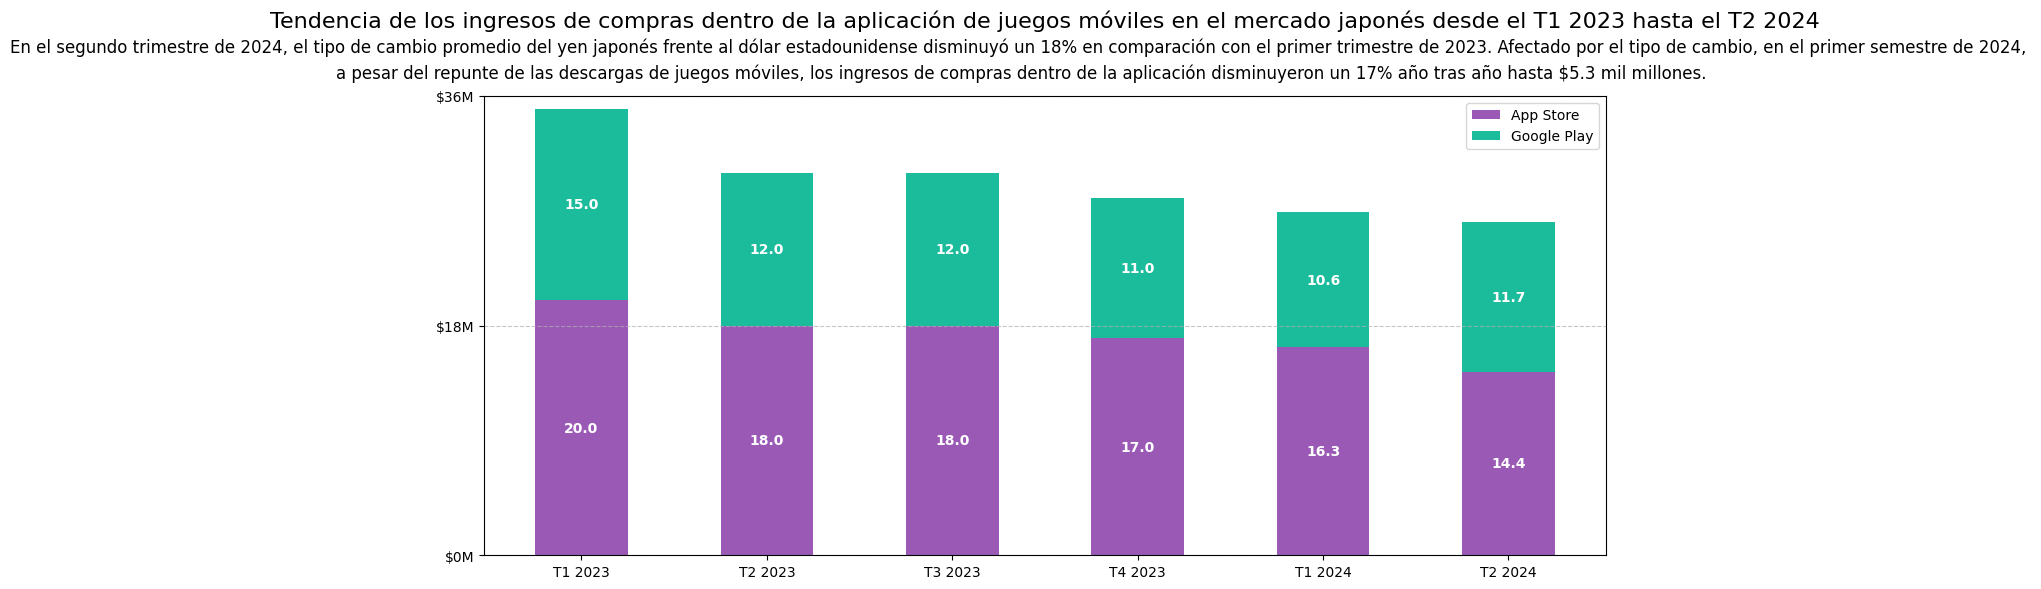

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Datos trimestrales
trimestres = ['T1 2023', 'T2 2023', 'T3 2023', 'T4 2023', 'T1 2024', 'T2 2024']
# Ingresos de compras dentro de la aplicación desde la App Store (en miles de millones de dólares estadounidenses, datos simulados cercanos a la proporción del gráfico)
app_store = [20, 18, 18, 17, 16.3, 14.4]
# Ingresos de compras dentro de la aplicación desde Google Play (en miles de millones de dólares estadounidenses, datos simulados cercanos a la proporción del gráfico)
google_play = [15, 12, 12, 11, 10.6, 11.7]

x = np.arange(len(trimestres))  # Posiciones de las marcas en el eje x
ancho = 0.5  # Ancho de las barras para que el gráfico sea más compacto y bonito

# Crear un lienzo y establecer el tamaño
fig, ax = plt.subplots(figsize=(12, 6))

# Dibujar las barras de la App Store (abajo, morado)
rects1 = ax.bar(x, app_store, ancho, label='App Store', color='#9b59b6')
# Dibujar las barras de Google Play (arriba, cian, apiladas sobre los datos de la App Store)
rects2 = ax.bar(x, google_play, ancho, bottom=app_store, label='Google Play', color='#1abc9c')

# Establecer las marcas y etiquetas del eje x, mostrarlas horizontalmente
ax.set_xticks(x)
ax.set_xticklabels(trimestres, rotation=0)

# Establecer el rango y las marcas del eje y para que coincidan con la escala de "0, 1.8, 3.6 miles de millones de dólares estadounidenses" del gráfico
ax.set_ylim(0, 36)
ax.set_yticks([0, 18, 36])
ax.set_yticklabels(['$0M', '$18M', '$36M'])

# Función para agregar etiquetas de datos, mostrando la altura de la barra (redondeada a 1 decimal)
def add_labels(rects, bottom_values=None):
    for i, rect in enumerate(rects):
        altura = rect.get_height()
        pos_y = bottom_values[i] + altura / 2 if bottom_values is not None else altura / 2
        ax.text(
            rect.get_x() + rect.get_width()/2.,
            pos_y,
            f'{altura:.1f}',  # Modificación clave: Forzar a mantener 1 decimal
            ha='center',
            va='center',
            color='white',
            fontweight='bold'
        )

add_labels(rects1)  # Etiquetas de datos de la App Store
add_labels(rects2, app_store)  # Etiquetas de datos de Google Play

# Configuración de la leyenda y el título
ax.legend(loc='upper right')
ax.set_title('Tendencia de los ingresos de compras dentro de la aplicación de juegos móviles en el mercado japonés desde el T1 2023 hasta el T2 2024', fontsize=16, pad=50)

# Agregar líneas de cuadrícula para ayudar a observar los datos
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Texto explicativo encima del gráfico, restaurando el contexto empresarial
texto = ("En el segundo trimestre de 2024, el tipo de cambio promedio del yen japonés frente al dólar estadounidense disminuyó un 18% en comparación con el primer trimestre de 2023. "
         "Afectado por el tipo de cambio, en el primer semestre de 2024, \na pesar del repunte de las descargas de juegos móviles, los ingresos de compras dentro de la aplicación disminuyeron un 17% año tras año hasta $5.3 mil millones.")
# Ajustar la posición del texto para evitar superposiciones con el título
fig.text(0.5, 0.89, texto, ha='center', va='center', fontsize=12, linespacing=1.5)

# Optimizar automáticamente el diseño para garantizar que los elementos no se amontonen
plt.tight_layout()

plt.show()